# Laboratorio 1 – Exploración, preparación y regresión lineal

**Curso:** ISIS2611

**Caso:** AlpesHearth

**Integrantes:**
- Nikol Katherin Rodriguez Ortiz - 202317538
- Daniel Bolivar Bernal - 202310329

---

## 1. Exploración de los datos
En esta sección se realiza una exploración inicial del conjunto de datos con el fin de entender su estructura, detectar valores faltantes, duplicados y posibles problemas de calidad.

In [273]:
import pandas as pd
import numpy as np
import seaborn as sns


train = pd.read_csv('Datos Lab 1.csv')
train_df = train.copy()
train_df.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


In [274]:
# Carga del diccionario de datos
dicc_pacientes = pd.read_excel('DiccPacientes.xlsx')
dicc_pacientes

,Nombre Columna,Tipo de dato,Comentarios
0,Patient ID,String,Identificador del paciente
1,Date of Service,Date,Fecha de la atención
2,Sex,String,"Sexo (Femenino, Masculino)"
3,Age,Integer,Edad
4,Weight (kg),Float,Peso
5,Height (m),Float,Altura
6,BMI,Float,Índice de masa corporal
7,Abdominal Circumference (cm),Float,Circunferencia abdominal
8,Blood Pressure (mmHg),String,"Presión sanguínea, de la forma ""<Presión arter..."
9,Total Cholesterol (mg/dL),Float,Colesterol total


In [275]:
# Información general del dataset
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient ID                    1639 non-null   object 
 1   Date of Service               1639 non-null   object 
 2   Sex                           1639 non-null   object 
 3   Age                           1571 non-null   float64
 4   Weight (kg)                   1566 non-null   float64
 5   Height (m)                    1578 non-null   float64
 6   BMI                           1586 non-null   float64
 7   Abdominal Circumference (cm)  1578 non-null   float64
 8   Blood Pressure (mmHg)         1639 non-null   object 
 9   Total Cholesterol (mg/dL)     1571 non-null   float64
 10  HDL (mg/dL)                   1557 non-null   float64
 11  Fasting Blood Sugar (mg/dL)   1585 non-null   float64
 12  Smoking Status                1639 non-null   object 
 13  Dia

In [276]:
# Estadísticas descriptivas
train_df.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1571.000000,1566.000000,1578.000000,1586.000000,1578.000000,1571.000000,1557.000000,1585.000000,1571.000000,1563.000000,1578.000000,1554.000000,1582.000000,1610.000000
mean,46.803186,85.666006,1.757439,28.424744,91.538861,199.043673,56.183558,117.836860,175.770082,0.522440,125.632637,82.887536,113.235896,18.227281
std,13.039479,21.712504,0.118012,7.309275,13.427985,59.388670,16.721702,32.379634,11.695880,0.085692,22.577463,15.503625,61.435291,10.767666
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000
25%,37.000000,67.100000,1.666500,22.600000,79.700000,150.000000,42.000000,92.000000,167.000000,0.453000,108.000000,71.000000,62.000000,15.150000
50%,46.000000,86.314000,1.760000,28.000000,91.200000,199.000000,56.000000,115.000000,176.000000,0.519000,125.000000,82.000000,112.000000,16.967000
75%,55.000000,104.801500,1.850000,33.963000,102.267250,250.000000,70.000000,139.000000,185.000000,0.582000,141.000000,93.000000,159.000000,18.900000
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000


In [277]:
# #  Instalaciones para el análisis exploratorio de datos
# %pip install ydata-profiling
# %pip show ydata-profiling
# from ydata_profiling import ProfileReport
# profile = ProfileReport(
#     train_df,
#     title="Reporte de Análisis Exploratorio",
#     explorative=True
# )

# profile.to_notebook_iframe()


### Alertas Detectadas en el Análisis Exploratorio

Durante el análisis exploratorio del dataset se identificaron múltiples alertas relacionadas con duplicados, correlaciones altas entre variables y valores faltantes. A continuación, se describen detalladamente los hallazgos y su impacto en el proceso de limpieza de datos.



#### 1. Filas Duplicadas

Se detectaron **151 filas duplicadas**, lo que corresponde al **9.2% del dataset**.

La presencia de duplicados puede generar varios problemas:
- Sesgos en análisis estadísticos.
- Sobreestimación de patrones.
- Impacto negativo en modelos predictivos.

**Decisión tomada:**  
Eliminar los duplicados para evitar redundancias y garantizar que cada registro represente una observación única.



#### 2. Altas Correlaciones entre Variables

Se identificaron múltiples pares de variables con correlaciones altas. Esto puede indicar:
- Redundancia de información.
- Posible multicolinealidad en modelos de machine learning.

##### Casos relevantes:

- **Altura en metros vs altura en centímetros**
  - `Height (m)` y `Height (cm)` contienen la misma información en distintas unidades.
  - **Decisión:** Mantener solo una representación (preferiblemente cm por legibilidad).

- **Circunferencia abdominal vs Waist-to-Height Ratio**
  - El ratio depende directamente de medidas físicas, por lo que la correlación es esperada.
  - **Decisión:** Mantener ambas si el ratio aporta valor clínico.

- **Colesterol total vs LDL estimado**
  - Alta correlación debido a su relación biomédica directa.
  - **Decisión:** Evaluar eliminar una variable si se requiere reducir dimensionalidad.

- **BMI con peso y riesgo cardiovascular**
  - El BMI es una variable derivada del peso y la altura, por lo que su correlación es lógica.
  - **Decisión:** Mantenerla por su relevancia clínica y uso estándar.

En general, las correlaciones fueron evaluadas considerando el contexto médico antes de eliminar variables.



#### 3. Valores Faltantes (Missing Values)

Se detectaron valores faltantes en múltiples variables, con porcentajes entre **1.8% y 5.2%**.

##### Variables con más datos faltantes:
- Diastolic BP (5.2%)
- HDL (5.0%)
- Waist-to-Height Ratio (4.6%)
- Weight (4.5%)

##### Variables con menor proporción:
- CVD Risk Score (1.8%)
- BMI (3.2%)
- Fasting Blood Sugar (3.3%)

Aunque ningún atributo supera el 10% de valores faltantes, la distribución es amplia en casi todas las columnas, lo que sugiere problemas en la recolección de datos.

**Decisión tomada:**
- No eliminar columnas completas, ya que el porcentaje de pérdida es moderado.
- Aplicar imputación dependiendo del tipo de variable:
  - Media o mediana para variables numéricas continuas.
  - Métodos derivados cuando la variable es calculable (ej. BMI).



#### 4. Impacto en la Calidad del Dataset

Los hallazgos indican que el dataset presenta problemas comunes en datos reales:

- Redundancia estructural (variables altamente correlacionadas).
- Inconsistencias por duplicación de registros.
- Valores faltantes distribuidos en múltiples atributos.

Sin embargo, la mayoría de los problemas son **corregibles mediante técnicas estándar de limpieza**, lo que hace viable su uso para análisis posteriores.



#### 5. Conclusión

El análisis de alertas permitió identificar los principales problemas de calidad en el dataset. Las decisiones tomadas priorizan:

- Preservar la mayor cantidad de información posible.
- Reducir redundancias innecesarias.
- Mantener variables clínicamente relevantes.
- Garantizar consistencia en el análisis posterior.

Estas acciones forman la base para una fase sólida de limpieza y transformación de datos, asegurando que el dataset esté en condiciones adecuadas para modelado y análisis estadístico.
    


## 2. Preparación de los datos
En esta sección se describen y justifican las decisiones de limpieza, transformación y selección de variables realizadas antes de entrenar los modelos.

### 2.1 Unicidad

En esta parte hacemos una verificación de valores duplicados.

In [278]:

train_df.duplicated().sum()

151

#### 2.1.1 Identificador único de pacientes

Se verificó que la columna Patient ID tuviera valores únicos para evitar duplicidad de registros.

**Justificación**

El identificador de paciente debe ser único en cualquier dataset clínico. La duplicación podría generar sesgos en el análisis, especialmente en métricas poblacionales o modelos predictivos.

No se realizaron modificaciones ya que los IDs eran únicos.

In [279]:


dup_counts = (train_df[["Patient ID"]].groupby('Patient ID').size().reset_index(name='Count').sort_values(by='Count', ascending=False))

dup_counts= dup_counts[dup_counts['Count']>1]

for id_, n in dup_counts[["Patient ID","Count"]].values:
    print(f"Id={id_} → {n} apariciones")


Id=bCoz6266 → 3 apariciones
Id=QJtE0701 → 3 apariciones
Id=NIUR3991 → 3 apariciones
Id=NOcd2332 → 3 apariciones
Id=DxSq2036 → 3 apariciones
Id=pEpZ9034 → 3 apariciones
Id=NvOx6625 → 3 apariciones
Id=oSqq7069 → 3 apariciones
Id=xFVW5778 → 3 apariciones
Id=DhUJ7239 → 3 apariciones
Id=nmgP2712 → 3 apariciones
Id=PHii0023 → 3 apariciones
Id=QAxZ5540 → 3 apariciones
Id=mrZW4662 → 3 apariciones
Id=DIVT3121 → 3 apariciones
Id=CKKa5109 → 3 apariciones
Id=miQs7675 → 3 apariciones
Id=mMoS9467 → 3 apariciones
Id=ltOL4864 → 3 apariciones
Id=lqUc7918 → 3 apariciones
Id=ChGR7779 → 3 apariciones
Id=RlsB8509 → 3 apariciones
Id=RwGu5647 → 3 apariciones
Id=CYeS2965 → 3 apariciones
Id=kijK0146 → 3 apariciones
Id=STpP5810 → 3 apariciones
Id=kajW6905 → 3 apariciones
Id=THSJ8564 → 3 apariciones
Id=NGwd5164 → 3 apariciones
Id=wWyM6139 → 3 apariciones
Id=LpyK7269 → 3 apariciones
Id=LdMm6225 → 3 apariciones
Id=GhAN9460 → 3 apariciones
Id=vKKa9024 → 3 apariciones
Id=HNpy8362 → 3 apariciones
Id=HNwp6592 → 3 apar

In [280]:
# Obtener IDs que están repetidos
ids_repetidos = train_df['Patient ID'][train_df.duplicated('Patient ID', keep=False)]

# Mostrar TODAS las filas y TODAS las columnas de esos IDs
train_df.loc[train_df['Patient ID'].isin(ids_repetidos)].sort_values('Patient ID')



,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
17,AhYt1346,09-28-2020,M,41.0,71.300,1.730,23.800,107.900,139/61,253.0,...,Low,Y,173.000,NaN,139.0,NaN,Hypertension Stage 1,146.0,16.770,HIGH
1584,AhYt1346,09-28-2020,M,41.0,71.300,1.730,23.800,107.900,139/61,253.0,...,Low,Y,173.000,NaN,139.0,NaN,Hypertension Stage 1,146.0,16.770,HIGH
1227,AhYt1346,09-28-2020,M,41.0,71.300,1.730,23.800,107.900,139/61,253.0,...,Low,Y,173.000,NaN,139.0,NaN,Hypertension Stage 1,146.0,-13.090,HIGH
1117,Axab9332,2021-12-11,F,58.0,69.870,1.944,20.785,86.259,162/106,151.0,...,Moderate,N,194.450,0.444,162.0,106.0,Hypertension Stage 2,44.0,23.430,HIGH
383,Axab9332,2021-12-11,F,58.0,69.870,1.944,20.785,86.259,162/106,151.0,...,Moderate,N,194.450,0.444,162.0,106.0,Hypertension Stage 2,44.0,15.277,HIGH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,zhZi8857,"December 05, 2025",F,36.0,81.200,1.750,26.500,74.000,141/76,225.0,...,Moderate,Y,175.000,0.423,141.0,NaN,Hypertension Stage 2,164.0,16.850,HIGH
727,zhZi8857,"December 05, 2025",F,36.0,81.200,1.750,26.500,74.000,141/76,225.0,...,Moderate,Y,175.000,0.423,141.0,NaN,Hypertension Stage 2,164.0,41.813,HIGH
1548,zhZi8857,"December 05, 2025",F,36.0,81.200,1.750,26.500,74.000,141/76,225.0,...,Moderate,Y,175.000,0.423,141.0,NaN,Hypertension Stage 2,164.0,16.850,HIGH
1565,zxhX5525,"November 13, 2021",M,26.0,58.953,1.688,25.286,NaN,110/114,258.0,...,High,Y,168.763,0.455,110.0,114.0,Hypertension Stage 2,170.0,15.717,HIGH


Como se observó anteriormente, las filas con IDs repetidos contienen exactamente la misma información en todas sus variables. Esto indica que se trata de duplicados completos y no de registros distintos con coincidencias parciales. Por esta razón, se tomó la decisión de eliminar todos los IDs repetidos, ya que no aportan información adicional al análisis y podrían sesgar los resultados estadísticos o los modelos posteriores.

In [281]:
# borrar los repetidos
train_df = train_df.sort_values('Date of Service').drop_duplicates(subset='Patient ID', keep='last')
train_df.duplicated(subset='Patient ID').sum()

0

### 2.2. Validez de los datos

#### 2.2.1 Corrección de validez: Normalización del tipo de dato en la variable Edad

**Decisión tomada**: Posterior a la normalización inicial de la variable Age, se realizó una limpieza adicional enfocada en garantizar consistencia y calidad estructural del dato. Primero, se redondearon los valores al entero más cercano para eliminar cualquier residuo decimal. Luego, se eliminaron los registros con valores nulos en la variable Age, ya que la edad es un atributo fundamental para el análisis y su ausencia podría introducir ruido o sesgos en modelos posteriores. Finalmente, se convirtió explícitamente el tipo de dato a entero para asegurar uniformidad en su representación y evitar inconsistencias en procesos de modelado o validación. Esta decisión prioriza la integridad del dataset, garantizando que la variable edad sea válida, consistente y directamente utilizable en etapas analíticas posteriores.

In [282]:
# Redondear edad al entero más cercano
train_df['Age'] = train_df['Age'].round()

# Droppeamos NaN
train_df = train_df.dropna(subset=['Age'])

# Convertir explícitamente a entero
train_df['Age'] = train_df['Age'].astype(int)


#### 2.2.2 Corrección de validez: Normalización del tipo de dato en la variable BMI

**Decisión tomada** : En el análisis de validez se identificó que la variable BMI contenía valores fuera de rangos fisiológicamente plausibles, específicamente un valor mínimo de 4.317 y valores cercanos a 53.028. Aunque el dataset puede incluir población infantil y casos de obesidad severa, un IMC de 4.317 resulta clínicamente inviable, ya que valores por debajo de 10 no son compatibles con condiciones reales de supervivencia humana y suelen indicar errores de medición o registro. Por otro lado, el valor máximo observado (53.028) sí puede corresponder a obesidad mórbida extrema, por lo que no se considera inválido.

Para garantizar la validez de los datos sin eliminar información útil, se optó por aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 10 y 80. Este enfoque permite conservar todos los registros, evitando pérdidas de información, mientras se corrigen valores claramente erróneos o producto de inconsistencias en la captura de datos. Además, esta técnica mantiene la distribución general de la variable sin introducir sesgos fuertes, a diferencia de eliminar registros o imputar valores artificiales.

In [283]:
train_df['BMI'] = train_df['BMI'].clip(lower=10, upper=80)

#### 2.2.3 Corrección de validez: Normalización del tipo de dato en la variable Total Cholesterol (mg/dL)

**Decisión tomada** : En el análisis de validez se identificó que la variable Total Cholesterol (mg/dL) presentaba valores fuera de rangos clínicamente plausibles, incluyendo valores negativos (como -1.256 mg/dL) y extremos elevados cercanos al límite superior observado en los datos. Un valor negativo de colesterol es fisiológicamente imposible, ya que esta medida representa una concentración en sangre y no puede ser menor a cero, lo que indica errores de captura o registro. Para corregir estas inconsistencias sin eliminar registros, se optó por aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 50 y 600 mg/dL. Este intervalo se eligió porque cubre desde niveles muy bajos clínicamente posibles hasta casos extremos de hipercolesterolemia, permitiendo mantener la variabilidad real del dataset mientras se eliminan valores inválidos. Esta decisión conserva la integridad de los datos y evita introducir sesgos derivados de la eliminación de registros o imputaciones artificiales.

In [284]:
train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].clip(lower=50, upper=600)

#### 2.2.4 Corrección de validez: Normalización del tipo de dato en la variable Total Cholesterol (mg/dL)

**Decisión tomada** : En el análisis de validez se observó que la variable HDL (mg/dL) presentaba valores fuera de rangos fisiológicamente plausibles, incluyendo valores extremadamente bajos cercanos a cero (como 0.008 mg/dL). Aunque el HDL puede variar entre individuos, valores cercanos a cero no son clínicamente realistas, ya que siempre existe una concentración mínima de lipoproteínas de alta densidad en sangre. Para corregir estas inconsistencias sin eliminar registros válidos, se aplicó una estrategia de recorte de valores (clipping), estableciendo un rango entre 10 y 150 mg/dL. Este intervalo abarca niveles muy bajos observables en poblaciones con alto riesgo cardiovascular hasta valores elevados presentes en individuos con perfiles lipídicos favorables. Esta decisión permite preservar la distribución general de los datos mientras se eliminan valores claramente erróneos, evitando introducir sesgos derivados de eliminaciones o imputaciones innecesarias.

In [285]:
train_df['HDL (mg/dL)'] = train_df['HDL (mg/dL)'].clip(lower=10, upper=150)

#### 2.2.5 Corrección de validez: Normalización del tipo de dato en la variable Fasting Blood Sugar (mg/dL)

**Decisión tomada** : En el análisis de validez se identificó que la variable Fasting Blood Sugar (mg/dL) presentaba valores fuera de rangos clínicamente plausibles, incluyendo niveles extremadamente bajos cercanos a 15 mg/dL. Aunque pueden existir valores bajos en casos de hipoglucemia, niveles por debajo de 40 mg/dL son considerados críticos y poco frecuentes en mediciones rutinarias, lo que sugiere posibles errores de captura o medición. Asimismo, se contempló la posibilidad de valores altos en pacientes con descontrol metabólico severo, por lo que se definió un rango amplio pero clínicamente razonable. Para garantizar la validez sin eliminar registros, se aplicó una estrategia de recorte (clipping) estableciendo límites entre 40 y 500 mg/dL. Este enfoque permite mantener la mayoría de observaciones reales, incluyendo casos extremos plausibles, mientras se eliminan valores claramente erróneos, preservando la distribución general de la variable sin introducir sesgos innecesarios.

In [286]:
train_df['Fasting Blood Sugar (mg/dL)'] = train_df['Fasting Blood Sugar (mg/dL)'].clip(lower=40, upper=500)

#### 2.2.6 Corrección de validez: Normalización del tipo de dato en la variable Waist-to-Height Ratio

**Decisión tomada** : Para mejorar la consistencia semántica de la variable Waist-to-Height Ratio (WHR), se verificó su coherencia respecto a su definición matemática, recalculándola a partir de la razón entre Abdominal Circumference (cm) y Height (cm). Se comparó el valor original con el recalculado y se estableció una tolerancia de 0.01 para identificar discrepancias menores atribuibles a errores de redondeo. En los casos donde la diferencia estuvo dentro de este umbral, se reemplazó el valor original por el recalculado, asegurando alineación exacta con la fórmula teórica sin alterar significativamente la distribución del dato. Finalmente, se redondeó la variable a tres decimales para mantener uniformidad en la precisión numérica y coherencia en su representación. Esta decisión permite estandarizar la variable derivada, reducir inconsistencias de cálculo y garantizar su validez para análisis posteriores.


In [287]:

calculated_whr = (
    train_df['Abdominal Circumference (cm)'] /
    train_df['Height (cm)']
)


difference = (
    train_df['Waist-to-Height Ratio'] - calculated_whr
).abs()


tolerance = 0.01


match_mask = difference <= tolerance


train_df.loc[match_mask, 'Waist-to-Height Ratio'] = calculated_whr[match_mask]


train_df['Waist-to-Height Ratio'] = \
    train_df['Waist-to-Height Ratio'].round(3)


#### 2.2.7 Corrección de validez: Normalización del tipo de dato en la variable Systolic BP

**Decisión tomada** : En el análisis de validez se identificó que la variable Systolic BP contenía valores fuera de rangos fisiológicamente plausibles. En la tabla de métricas inicial se observaron valores extremos, como mínimos cercanos a 49 mmHg y máximos superiores a 200 mmHg, que pueden corresponder a errores de medición, digitación o inconsistencias en la captura de datos. Desde el punto de vista clínico, aunque la presión sistólica puede variar ampliamente según la condición del paciente, valores por debajo de 70 mmHg suelen asociarse a estados críticos poco frecuentes en mediciones rutinarias, mientras que valores superiores a 250 mmHg son extremadamente raros y generalmente corresponden a errores. Por esta razón, se optó por aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 70 y 250 mmHg. Esta decisión permite mantener todos los registros, evitando pérdida de información, mientras se corrigen valores claramente inválidos y se preserva la coherencia clínica de la variable sin introducir sesgos artificiales.

In [288]:
train_df['Systolic BP'] = train_df['Systolic BP'].clip(lower= 70, upper= 250)

#### 2.2.8 Corrección de validez: Normalización del tipo de dato en la variable Diastolic BP

**Decisión tomada** : En el análisis de validez se identificó que la variable Diastolic BP contenía valores fuera de rangos fisiológicamente plausibles. En la tabla de métricas inicial se observaron valores extremos que se alejaban de lo esperado en mediciones clínicas normales, lo cual puede estar asociado a errores de digitación, fallos en los dispositivos de medición o inconsistencias en la recolección de datos. Desde el punto de vista clínico, aunque la presión diastólica puede variar entre individuos, valores por debajo de 40 mmHg suelen indicar estados de hipotensión severa poco frecuentes en contextos poblacionales, mientras que valores superiores a 150 mmHg corresponden a crisis hipertensivas graves y extremadamente raras en estudios generales, por lo que es más probable que representen errores. Por esta razón, se optó por aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 40 y 150 mmHg. Esta decisión permite conservar todos los registros sin eliminarlos, corrigiendo valores claramente inválidos y manteniendo la coherencia clínica de la variable sin introducir distorsiones significativas en el análisis.

In [289]:
train_df['Diastolic BP'] = train_df['Diastolic BP'].clip(lower= 40, upper= 150)

#### 2.2.9 Corrección de validez: Normalización del tipo de dato en la variable Estimated LDL (mg/dL)

**Decisión tomada** : En el análisis de validez se identificó que la variable Estimated LDL (mg/dL) presentaba valores fuera de rangos clínicamente plausibles. En la tabla de métricas inicial se observaron valores mínimos y máximos que se alejaban de los niveles esperados para el colesterol LDL en población general, lo cual puede atribuirse a errores de medición, digitación o inconsistencias en la estimación del valor. Desde el punto de vista clínico, aunque el LDL puede variar dependiendo del perfil metabólico del paciente, valores por debajo de 90 mg/dL son poco comunes cuando se trata de estimaciones poblacionales sin intervención farmacológica, mientras que valores superiores a 200 mg/dL corresponden a hipercolesterolemia severa y son relativamente raros en estudios generales, por lo que podrían reflejar errores en los datos. Por esta razón, se decidió aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 90 y 200 mg/dL. Esta decisión permite conservar todos los registros sin eliminarlos, corrigiendo valores claramente inconsistentes y manteniendo la coherencia clínica de la variable sin introducir sesgos significativos en el análisis.


In [290]:
train_df['Estimated LDL (mg/dL)'] = train_df['Estimated LDL (mg/dL)'].clip(lower= 90, upper= 200)

#### 2.2.10 Corrección de validez: Normalización del tipo de dato en la variable CVD Risk Score

**Decisión tomada** : En el análisis de validez se identificó que la variable CVD Risk Score contenía valores fuera de los límites lógicos esperados para una puntuación de riesgo cardiovascular. En la tabla de métricas inicial se observaron valores mínimos negativos y máximos superiores a 100, lo cual no es consistente con la naturaleza de esta variable, ya que representa una probabilidad o índice porcentual de riesgo. Desde el punto de vista conceptual y clínico, un puntaje de riesgo cardiovascular debe estar acotado entre 0 y 100, donde 0 indica ausencia de riesgo y 100 representa el nivel máximo posible. Valores por debajo de 0 o por encima de 100 suelen originarse por errores de cálculo, transformación o captura de datos. Por esta razón, se optó por aplicar una estrategia de recorte de valores (clipping), estableciendo un rango entre 0 y 100. Esta decisión permite conservar todos los registros, corrigiendo valores inválidos sin eliminar información, y asegura la coherencia semántica de la variable sin introducir sesgos artificiales en el análisis.

In [291]:
train_df['CVD Risk Score'] = train_df['CVD Risk Score'].clip(lower=0, upper=100)

### 2.3. Consistencia de los datos

En esta sección se evaluó la consistencia interna del dataset, es decir, que los valores de cada variable fueran coherentes entre sí y con las reglas del dominio clínico. Se analizaron relaciones entre variables derivadas, formatos duplicados y coherencia entre columnas relacionadas.

#### 2.3.1 Consistecia de Patient ID

In [292]:
train_df['Patient ID'].value_counts()

Patient ID
QgsB2968    1
jPFA2042    1
vAJO9000    1
CFVK4196    1
Pymh0850    1
           ..
fnuM0476    1
kxWi2841    1
qcdy4813    1
rBZy3314    1
syIz2350    1
Name: count, Length: 1317, dtype: int64

#### 2.3.2 Consistecia de Smoking Status

In [293]:
train_df['Smoking Status'].value_counts()

Smoking Status
Y    678
N    639
Name: count, dtype: int64

#### 2.3.3 Consistecia de Diabetes Status

In [294]:
train_df['Diabetes Status'].value_counts()

Diabetes Status
Y    670
N    647
Name: count, dtype: int64

#### 2.3.4 Consistecia de Physical Activity Level

In [295]:
train_df['Physical Activity Level'].value_counts()

Physical Activity Level
High        450
Moderate    441
Low         426
Name: count, dtype: int64

#### 2.3.5 Consistecia de Family History of CVD

In [296]:
train_df['Family History of CVD'].value_counts()

Family History of CVD
N    670
Y    647
Name: count, dtype: int64

#### 2.3.6 Consistecia de Blood Pressure Category

In [297]:
train_df['Blood Pressure Category'].value_counts()

Blood Pressure Category
Hypertension Stage 2    542
Hypertension Stage 1    428
Normal                  259
Elevated                 88
Name: count, dtype: int64

#### 2.3.7 Consistecia de Sex

In [298]:
train_df['Sex'].value_counts()

Sex
F    667
M    650
Name: count, dtype: int64

Anteriormente se revisaron todas las variables categóricas (tipo object) con el objetivo de identificar posibles categorías duplicadas, inconsistencias en la escritura o valores mal registrados. Tras esta verificación, se observó que las categorías presentes en cada variable eran únicas y coherentes, por lo que no fue necesario realizar procesos de normalización adicionales.

Adicionalmente, como se mencionó en la sección de completitud, se eliminó la columna Height (m) con el fin de mantener consistencia en las unidades de medida, conservando únicamente la altura en centímetros. Esta decisión permitió evitar redundancias y garantizar mayor coherencia estructural en el dataset.

### 2.4 Completitud (Valores faltantes)

Se detectaron múltiples columnas con valores faltantes.
Se utilizó una estrategia jerárquica:

- Imputación basada en correlación (preferida)

- Imputación por mediana (respaldo)

- Eliminación solo en casos mínimos

In [299]:

def resumen_nulos(df):
    total = df.isnull().sum()
    porcentaje = (total / len(df)) * 100

    resumen = pd.DataFrame({
        'Variable': total.index,
        'Nulos': total.values,
        'Porcentaje (%)': porcentaje.values.round(2)
    })

    # Solo variables con nulos
    resumen = resumen[resumen['Nulos'] > 0]

    # Ordenar
    resumen = resumen.sort_values(by='Porcentaje (%)', ascending=False).reset_index(drop=True)

    return resumen

resumen_nulos(train_df)

,Variable,Nulos,Porcentaje (%)
0,HDL (mg/dL),65,4.94
1,Weight (kg),62,4.71
2,Waist-to-Height Ratio,62,4.71
3,Diastolic BP,58,4.40
4,Total Cholesterol (mg/dL),53,4.02
5,Height (cm),53,4.02
6,Systolic BP,50,3.80
7,Height (m),48,3.64
8,Abdominal Circumference (cm),48,3.64
9,Fasting Blood Sugar (mg/dL),47,3.57


#### 2.4.1 Corrección de completitud: Imputación de valores nulos a Peso de BMI

**Decisión tomada**: Para la corrección de completitud de la variable Weight (kg) se identificó que presentaba un 4.71% de valores faltantes, mientras que la variable BMI tenía un 3.34%, y dado que ambas están fuertemente relacionadas desde el punto de vista matemático y clínico, se optó por una imputación basada en su relación estructural. Primero se estimó una constante proporcional usando la mediana de la razón Weight/BMI para evitar la influencia de valores atípicos, y con esta se imputaron los pesos faltantes a partir del BMI, preservando coherencia fisiológica entre variables y evitando sesgos arbitrarios. Posteriormente, los valores se redondearon para mantener consistencia con mediciones reales y se aplicó un recorte de valores extremos con el fin de evitar resultados fuera de rango. Finalmente, en los casos donde la imputación relacional no fue posible (por ausencia simultánea de BMI), se utilizó una imputación por mediana como estrategia de respaldo, ya que es robusta frente a outliers y adecuada cuando el porcentaje de datos faltantes es moderado. Esta estrategia híbrida permitió conservar la mayor cantidad de registros posibles, mantener relaciones estadísticas del dataset y minimizar el sesgo introducido por imputaciones simples.

In [300]:
k = (train_df['Weight (kg)'] / train_df['BMI']).dropna().median()

train_df  = train_df.fillna({'Weight (kg)': k * train_df['BMI']})

train_df['Weight (kg)'] =  train_df['Weight (kg)'].round()

train_df['Weight (kg)'] = train_df['Weight (kg)'].clip(lower=13.261000, upper= 158.523000)

# guardamos el dato de si se imputo o no el dato de Weight (kg)
train_df['Weight_imputed_median'] = train_df['Weight (kg)'].isnull()


train_df['Weight (kg)'] = train_df['Weight (kg)'].fillna(train_df['Weight (kg)'].median())


#### 2.4.2 Corrección de completitud: Imputación de valores nulos de BMI con Peso

**Decisión tomada**: Para la imputación de los valores faltantes en la variable BMI, se aprovechó la relación existente entre esta variable y el peso, ya que ambas están fuertemente correlacionadas. Sin embargo, para evitar introducir sesgos adicionales en el cálculo, se utilizaron únicamente los registros cuyo peso no había sido previamente imputado por mediana. Esto fue posible gracias a que en etapas anteriores se creó una columna auxiliar que identifica qué valores de peso fueron imputados. De esta forma, el factor de conversión entre BMI y peso se calculó únicamente con datos originales, reduciendo la propagación de errores derivados de imputaciones previas. Posteriormente, los valores faltantes de BMI se estimaron a partir de este factor y del peso disponible, se redondearon para mantener coherencia con la precisión del dataset y se limitaron a un rango válido para evitar valores atípicos. Finalmente, los pocos valores restantes sin estimar se imputaron mediante la mediana, garantizando la completitud de la variable sin introducir un sesgo significativo en la distribución general.

In [301]:
valid_rows = train_df['Weight_imputed_median'] == False

k = (
    train_df.loc[valid_rows, 'BMI'] /
    train_df.loc[valid_rows, 'Weight (kg)']
).median()

train_df['BMI'] = train_df['BMI'].fillna(
    k * train_df['Weight (kg)']
)

train_df['BMI'] = \
    train_df['BMI'].round(2)

train_df['BMI'] = \
    train_df['BMI'].clip(
        lower=10,
        upper=80
    )

train_df['BMI'] = train_df['BMI'].fillna(train_df['BMI'].median())


#### 2.4.3 Corrección de completitud: Eliminación de las filas sin CVD Risk Score

**Decisión tomada**: En este caso, los valores faltantes de CVD Risk Score no serán imputados debido a que esta variable objetivo. Imputar esta variable crearia una relación circular artificial entre una feature y el target. Por ende se decide eliminar las filas con valores faltantes en esta variable.


In [302]:
train_df = train_df.dropna(subset=['CVD Risk Score'])


#### 2.4.4 Corrección de completitud: Imputación de valores nulos de Altura cm con Altura m

**Decisión tomada**: En este caso identificamos que existían dos variables que representaban la misma información en diferentes unidades: Height (m) y Height (cm). Al analizar la completitud, observamos que la altura en metros tenía menos valores faltantes, por lo que se decidió utilizarla como fuente para completar la altura en centímetros. Para ello, primero se realizó la conversión de metros a centímetros y posteriormente se imputaron los valores faltantes de Height (cm) usando esta transformación. Una vez consolidada la información en una sola unidad, se eliminó la columna Height (m) para evitar redundancias y problemas de multicolinealidad en análisis posteriores. Finalmente, se eliminaron los pocos registros que aún presentaban valores nulos en la altura consolidada, garantizando consistencia en la variable.


In [303]:

height_m_to_cm = train_df['Height (m)'] * 100


train_df['Height (cm)'] = train_df['Height (cm)'].fillna(height_m_to_cm)


train_df = train_df.drop(columns=['Height (m)'])

train_df = train_df.dropna(subset=['Height (cm)'])

print(train_df["Height (cm)"].isnull().mean() * 100)

0.0


#### 2.4.5 Corrección de completitud: Imputación de valores nulos con medida de tendencia central de Systolic BP, Diastolic BD, 'Fasting Blood Sugar (mg/dL)' y HDL (mg/dL).

**Decisión tomada**: En el caso de Systolic BP, Diastolic BP, Fasting Blood Sugar (mg/dL) y HDL (mg/dL), se identificó que estas variables presentaban valores faltantes y no contaban con una correlación suficientemente fuerte con otras variables del dataset que permitiera realizar una imputación basada en relaciones estadísticas confiables. Además, eliminar los registros con datos faltantes en estas columnas habría reducido innecesariamente el tamaño de la muestra y podría introducir sesgos en el análisis, especialmente al tratarse de variables clínicas relevantes para el estudio cardiovascular.

Por esta razón, se optó por una imputación mediante mediana, ya que este método es robusto frente a valores atípicos y permite conservar la distribución general de los datos. Esta decisión garantiza mantener la mayor cantidad de información posible sin introducir sesgos significativos derivados de imputaciones complejas o eliminaciones de registros.



In [304]:
train_df['Systolic BP'] = train_df['Systolic BP'].fillna(train_df['Systolic BP'].median())

train_df['Diastolic BP'] = train_df['Diastolic BP'].fillna(train_df['Diastolic BP'].median())

train_df['Fasting Blood Sugar (mg/dL)']= train_df['Fasting Blood Sugar (mg/dL)']. fillna(train_df['Fasting Blood Sugar (mg/dL)'].median())
train_df['HDL (mg/dL)']= train_df['HDL (mg/dL)'].fillna(train_df['HDL (mg/dL)'].median())

#### 2.4.6 Corrección de completitud:  Imputación de valores nulos de Waist-to-Height Ratio con circunferencia abdominal

**Decisión tomada**: En la variable **Waist-to-Height Ratio** se decidió aplicar una imputación basada en otra variable en lugar de usar directamente la media o mediana. Esta decisión se tomó porque existe una relación fuerte y lógica con la **circunferencia abdominal**, lo que permite estimar valores faltantes de forma más contextualizada y coherente desde el punto de vista clínico. Usar únicamente una medida de tendencia central habría ignorado esta relación estructural entre variables y podría introducir mayor sesgo en la distribución. Por ello, primero se realizó una imputación basada en la variable correlacionada para preservar la estructura de los datos, y posteriormente se utilizó la mediana solo como respaldo en los pocos casos donde aún persistían valores faltantes, garantizando así completitud sin distorsionar significativamente el comportamiento original de la variable.


In [305]:


k = (train_df['Waist-to-Height Ratio'] / train_df['Abdominal Circumference (cm)']).dropna().median()

train_df  = train_df.fillna({'Waist-to-Height Ratio': k * train_df['Abdominal Circumference (cm)']})

train_df['Waist-to-Height Ratio'] =  train_df['Waist-to-Height Ratio'].round(3)

train_df['Waist-to-Height Ratio'] = train_df['Waist-to-Height Ratio'].clip(lower=0.085692, upper=  0.804000)

# guardamos el dato de si se imputo o no el dato de Waist-to-Height Ratio
train_df['WHR_imputed_median'] = train_df['Waist-to-Height Ratio'].isnull()


train_df['Waist-to-Height Ratio'] = train_df['Waist-to-Height Ratio'].fillna(train_df['Waist-to-Height Ratio'].median())

#### 2.4.7 Corrección de completitud: Imputación de valores nulos de circunferencia abdominal con Waist-to-Height Ratio.

**Decisión tomada**: Para la variable **Abdominal Circumference (cm)** se aplicó una imputación basada en su relación con **Waist-to-Height Ratio**, ya que ambas variables están fuertemente correlacionadas y representan medidas antropométricas directamente relacionadas. Sin embargo, se tuvo una precaución importante: previamente habíamos marcado cuáles valores de Waist-to-Height Ratio fueron imputados con la mediana. Por esta razón, al estimar los valores faltantes de circunferencia abdominal, solo se utilizaron registros confiables (es decir, aquellos que no provenían de imputaciones por tendencia central). Esto se hizo para evitar la propagación de sesgo, ya que imputar una variable a partir de otra que ya fue imputada con la mediana puede amplificar errores o artificialmente reducir la variabilidad. Finalmente, en los pocos casos restantes donde aún persistían valores faltantes, se utilizó la mediana como respaldo para asegurar la completitud del dataset sin comprometer la coherencia estadística.


In [306]:
valid_rows = train_df['WHR_imputed_median'] == False

k = (
    train_df.loc[valid_rows, 'Abdominal Circumference (cm)'] /
    train_df.loc[valid_rows, 'Waist-to-Height Ratio']
).median()

train_df['Abdominal Circumference (cm)'] = train_df['Abdominal Circumference (cm)'].fillna(
    k * train_df['Waist-to-Height Ratio']
)

train_df['Abdominal Circumference (cm)'] = \
    train_df['Abdominal Circumference (cm)'].round(2)

train_df['Abdominal Circumference (cm)'] = \
    train_df['Abdominal Circumference (cm)'].clip(
        lower=49.542000 ,
        upper=136.336000
    )

train_df['Abdominal Circumference (cm)'] = train_df['Abdominal Circumference (cm)'].fillna(train_df['Abdominal Circumference (cm)'].median())


#### 2.4.8 Corrección de completitud: Imputación de valores nulos de Total Cholesterol (mg/dL) con Estimated LDL (mg/dL).

**Decisión tomada**: Para la variable **Total Cholesterol (mg/dL)** se optó por una estrategia de imputación basada en otra variable debido a su alta correlación con **Estimated LDL (mg/dL)**, lo cual tiene respaldo clínico, ya que ambas representan componentes del perfil lipídico. Inicialmente se almacenó una marca que indicara cuáles valores eran originalmente nulos, con el fin de mantener trazabilidad sobre las imputaciones realizadas. Luego, los valores faltantes se estimaron utilizando la relación proporcional con LDL, preservando así la coherencia entre variables altamente relacionadas y evitando distorsionar la distribución con una imputación simple. Posteriormente, se normalizaron los valores mediante redondeo y recorte dentro de rangos válidos para asegurar consistencia estadística. Finalmente, en los pocos casos donde aún persistían valores faltantes, se utilizó la mediana como método de respaldo para garantizar la completitud del dataset sin perder la estructura original de los datos ni introducir sesgos significativos.


In [307]:

train_df['TC_missing_original'] = train_df['Total Cholesterol (mg/dL)'].isnull()


k = (
    train_df['Total Cholesterol (mg/dL)'] /train_df['Estimated LDL (mg/dL)']).dropna().median()



train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].fillna( k * train_df['Estimated LDL (mg/dL)']
    )



train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].round()



train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].clip(lower=59.388670, upper=385.679000)

# guardamos el dato de si se imputo o no el dato de Waist-to-Height Ratio
train_df['TC_imputed_median'] = train_df['Total Cholesterol (mg/dL)'].isnull()



train_df['Total Cholesterol (mg/dL)'] = train_df['Total Cholesterol (mg/dL)'].fillna( train_df['Total Cholesterol (mg/dL)'].median())





#### 2.4.9 Corrección de completitud: Imputación de valores nulos de Estimated LDL (mg/dL)   con Total Cholesterol (mg/dL).

**Decisión tomada**: Para la variable Estimated LDL (mg/dL) se aplicó una imputación basada en su relación con Total Cholesterol (mg/dL), aprovechando la alta correlación previamente identificada entre ambas variables. Sin embargo, para evitar la propagación de sesgos, se decidió utilizar únicamente las filas donde el colesterol total no había sido imputado con la mediana, garantizando así que la relación utilizada proviniera de datos más confiables. Esta precaución permitió mantener la coherencia entre variables sin amplificar errores derivados de imputaciones previas. Posteriormente, los valores estimados fueron ajustados mediante redondeo y acotados dentro de un rango válido para preservar la consistencia estadística. Finalmente, en los pocos casos restantes donde aún había valores faltantes, se utilizó la mediana como estrategia de respaldo, asegurando la completitud del dataset sin comprometer la calidad global de los datos.

In [308]:
valid_rows1 = train_df['TC_imputed_median'] == False

k = (
    train_df.loc[valid_rows1,'Estimated LDL (mg/dL)'] /
    train_df.loc[valid_rows1, 'Total Cholesterol (mg/dL)']
).median()

train_df['Estimated LDL (mg/dL)'] = train_df['Estimated LDL (mg/dL)'].fillna(
    k * train_df['Total Cholesterol (mg/dL)']
)

train_df['Estimated LDL (mg/dL)'] = \
    train_df['Estimated LDL (mg/dL)'].round(2)

train_df['Estimated LDL (mg/dL)'] = \
    train_df['Estimated LDL (mg/dL)'].clip(
        lower=  61.435291 ,
        upper= 317.314000
    )

train_df['Estimated LDL (mg/dL)'] = train_df['Estimated LDL (mg/dL)'].fillna(train_df['Estimated LDL (mg/dL)'].median())



## 3. Eliminación de Outliers

Para la detección y tratamiento de valores atípicos se aplicó el método del rango intercuartílico (IQR) sobre todas las variables numéricas del dataset, excluyendo columnas auxiliares generadas durante procesos de imputación para evitar sesgos en la detección. Según este criterio, un dato se considera outlier si se encuentra fuera del intervalo $[Q_1 - 1.5 \cdot IQR,\ Q_3 + 1.5 \cdot IQR]$.
​representan los percentiles 25 y 75 respectivamente. Se calcularon estos límites de forma independiente para cada variable y se generó un reporte detallado con los umbrales y la cantidad de valores atípicos detectados. Posteriormente, se eliminaron las filas que presentaban outliers en al menos una variable numérica, con el objetivo de reducir el ruido extremo y mejorar la estabilidad de análisis estadísticos y modelos posteriores. Este enfoque conservador prioriza la calidad global del dataset, garantizando distribuciones más robustas y evitando que valores extremos distorsionen los resultados analíticos.



Columnas numericas para detección de outliers: ['Age', 'Weight (kg)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)', 'CVD Risk Score']
Shape antes de eliminar outliers: (1287, 27)


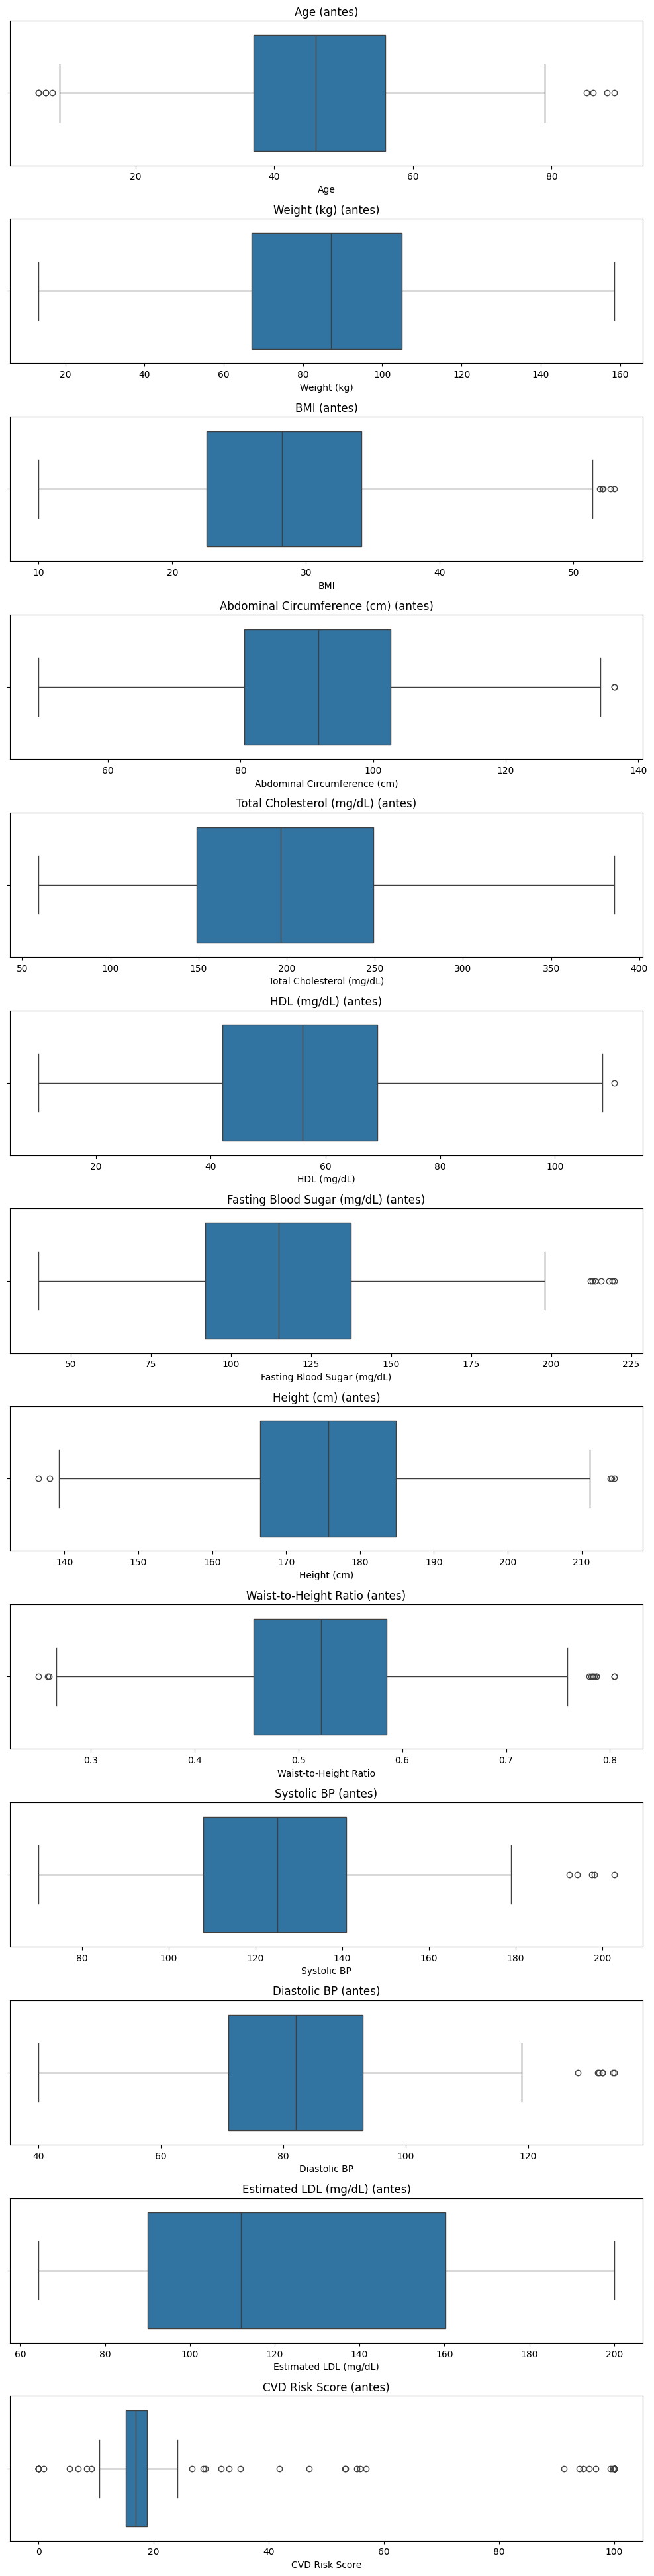


Reporte de outliers por variable:
                                   Q1        Q3       IQR      lower      upper  n_outliers
Age                            37.000   56.0000   19.0000    8.50000   84.50000         9.0
Weight (kg)                    67.000  105.0000   38.0000   10.00000  162.00000         0.0
BMI                            22.570   34.1400   11.5700    5.21500   51.49500         5.0
Abdominal Circumference (cm)   80.545  102.6100   22.0650   47.44750  135.70750         2.0
Total Cholesterol (mg/dL)     149.000  249.0000  100.0000   -1.00000  399.00000         0.0
HDL (mg/dL)                    42.000   69.0000   27.0000    1.50000  109.50000         1.0
Fasting Blood Sugar (mg/dL)    92.000  137.5000   45.5000   23.75000  205.75000         7.0
Height (cm)                   166.505  184.8405   18.3355  139.00175  212.34375         5.0
Waist-to-Height Ratio           0.457    0.5850    0.1280    0.26500    0.77700        12.0
Systolic BP                   108.000  141.00

In [309]:
import matplotlib.pyplot as plt

# Variables numericas sobre las que aplicar IQR
numeric_cols_iqr = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Excluir columnas auxiliares de imputación y el target
cols_excluir = [
    'Weight_imputed_median',
    'WHR_imputed_median',
    'TC_missing_original',
    'TC_imputed_median',
]
numeric_cols_iqr = [c for c in numeric_cols_iqr if c not in cols_excluir]

print(f"Columnas numericas para detección de outliers: {numeric_cols_iqr}")
print(f"Shape antes de eliminar outliers: {train_df.shape}")

# Boxplots ANTES de eliminar outliers
fig, axes = plt.subplots(nrows=len(numeric_cols_iqr), ncols=1,
                         figsize=(10, 3 * len(numeric_cols_iqr)))
for i, col in enumerate(numeric_cols_iqr):
    sns.boxplot(x=train_df[col], ax=axes[i])
    axes[i].set_title(f'{col} (antes)')
plt.tight_layout()
plt.show()

# Metodo IQR: eliminar filas que sean outlier en CUALQUIER variable numerica
mask = pd.Series(True, index=train_df.index)

outlier_report = {}
for col in numeric_cols_iqr:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    col_mask = train_df[col].between(lower, upper)
    # ~ es un NOT bit a bit que invierte la mascara, es decir,
    # True se vuelve False y viceversa, por lo que ~col_mask es
    # True para las filas que son outliers en esa variable
    n_outliers = (~col_mask).sum()
    outlier_report[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower': lower,
        'upper': upper,
        'n_outliers': n_outliers
    }
    # Esta linea lo que hace es que acumula la mascara global de filas a eliminar, es decir, si una fila es outlier en cualquier variable, se marcará como False en la mascara final
    mask &= col_mask

outlier_df = pd.DataFrame(outlier_report).T
print("\nReporte de outliers por variable:")
print(outlier_df.to_string())

train_df = train_df[mask].reset_index(drop=True)
print(f"\nShape después de eliminar outliers: {train_df.shape}")
print(f"Filas eliminadas: {(~mask).sum()}")

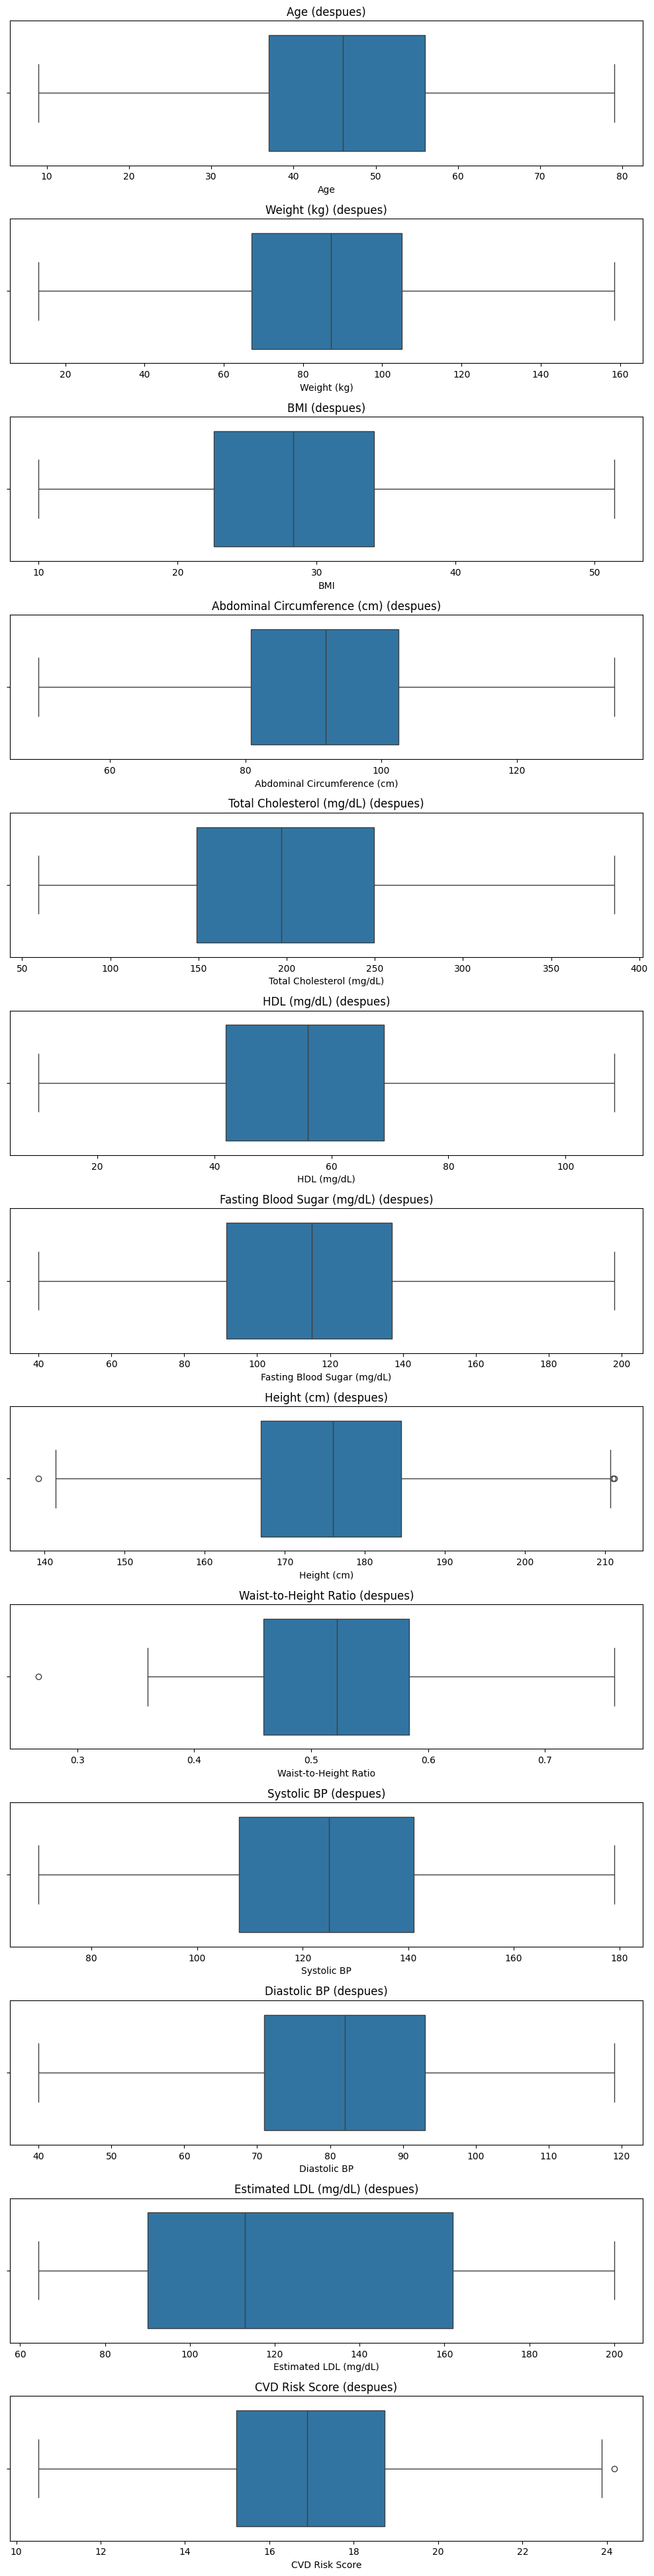

In [310]:
# Boxplots DESPUES de eliminar outliers
fig, axes = plt.subplots(nrows=len(numeric_cols_iqr), ncols=1,
                         figsize=(10, 3 * len(numeric_cols_iqr)))
for i, col in enumerate(numeric_cols_iqr):
    sns.boxplot(x=train_df[col], ax=axes[i])
    axes[i].set_title(f'{col} (despues)')
plt.tight_layout()
plt.show()

## 4. Construcción de modelos de regresión lineal
Se construyen al menos dos modelos de regresión lineal utilizando diferentes estrategias de preparación de datos y pipelines.

### Importamos las librerias necesarias

In [311]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_regression
from scipy.stats import pointbiserialr


#### 4.1 Selección y depuración de variables para el modelado predictivo

 **Decisión tomada**: Se realizó una selección cuidadosa de variables antes del modelado con el objetivo de evitar sesgos, redundancias y fugas de información (data leakage). En primer lugar, se eliminaron identificadores únicos como Patient ID, ya que no aportan valor predictivo y pueden inducir sobreajuste. También se excluyeron variables auxiliares creadas durante el preprocesamiento (indicadores de imputación), debido a que reflejan artefactos del pipeline y no características reales del paciente. Se removieron variables con riesgo de fuga de información, como CVD Risk Level, al estar directamente relacionadas con el target, y atributos no informativos como Date of Service. Asimismo, se descartaron variables redundantes, por ejemplo Blood Pressure (mmHg), que ya está descompuesta en presión sistólica y diastólica, evitando multicolinealidad. Finalmente, se separó el target (CVD Risk Score) del conjunto de predictores y se identificaron automáticamente las variables numéricas y categóricas para facilitar pasos posteriores de modelado, como escalado o codificación. Esta depuración garantiza un conjunto de características más limpio, interpretable y adecuado para entrenar modelos robustos.

In [312]:
# Definimos las variables a excluir del modelo
cols_to_drop = [
    'Patient ID', # El id no aporta información relevante para el modelo
    # Variables que indican si se imputó o no un valor, ya que el modelo no debería basarse en eso
    'Weight_imputed_median',
    'WHR_imputed_median',
    'TC_missing_original',
    'TC_imputed_median',
    'CVD Risk Level', # Data Leak
    'Date of Service', # No aporta información relevante para el modelo
    'Blood Pressure (mmHg)', # Redundante con Systolic BP y Diastolic BP
    #'Waist-to-Height Ratio',  # Redundante: es Abdominal Circumference / Height
]

target = 'CVD Risk Score'

X = train_df.drop(columns=cols_to_drop + [target])
y = train_df[target]

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Características numéricas:", numeric_features)
print("Características categóricas:", categorical_features)


Características numéricas: ['Weight (kg)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']
Características categóricas: ['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category']


#### 4.2 Definición de transformadores y construcción del preprocesador para el modelo

 **Decisión tomada**: Se diseñó un pipeline de preprocesamiento estructurado para garantizar un tratamiento adecuado y consistente de las variables antes del modelado. Para las características numéricas, se aplicó un proceso de estandarización mediante StandardScaler, transformándolas a una distribución con media 0 y desviación estándar 1. Esta normalización permite que los modelos sean menos sensibles a diferencias de escala entre variables y mejora la convergencia en algoritmos que dependen de distancias o gradientes. Por otro lado, las variables categóricas se transformaron utilizando OneHotEncoder, generando representaciones binarias que permiten a los modelos interpretar categorías de forma no ordinal, evitando introducir relaciones artificiales entre valores. Finalmente, ambos transformadores se integraron mediante un ColumnTransformer, lo que permite aplicar automáticamente el procesamiento adecuado según el tipo de variable dentro de un flujo unificado y reproducible. Esta estrategia asegura coherencia en el preprocesamiento, facilita la integración con pipelines de modelado y reduce el riesgo de errores durante entrenamiento y despliegue.

In [313]:
# Transformador para características numéricas
# Esto lo que hace es escalar las características
# para que tengan media 0 y desviación estándar 1.


numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Transformador para características categóricas
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinamos los transformadores en un preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


#### 4.3 División del dataset en conjuntos de entrenamiento y prueba

**Decisión tomada**: Se realizó una partición del dataset en conjuntos de entrenamiento y prueba con el objetivo de evaluar de forma realista el desempeño del modelo. Se utilizó una división del 70% para entrenamiento y 30% para prueba, permitiendo contar con suficiente información para el aprendizaje sin comprometer la capacidad de validación externa. Además, se estableció un valor fijo de random_state=42 para garantizar la reproducibilidad de los resultados, asegurando que futuras ejecuciones del experimento generen la misma partición de datos. Esta estrategia permite evaluar la capacidad de generalización del modelo sobre datos no vistos, reduciendo el riesgo de sobreajuste y proporcionando métricas de rendimiento más confiables.

In [314]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

#### 4.4 Modelo base de regresión lineal con todas las variables

**Decisión tomada**: Como punto de partida para el análisis predictivo, se construyó un modelo base de regresión lineal utilizando todas las variables disponibles tras el preprocesamiento. El modelo se implementó mediante un Pipeline que integra el preprocesador previamente definido y un estimador de LinearRegression, asegurando que las transformaciones se apliquen de forma consistente tanto en entrenamiento como en inferencia. Posteriormente, el modelo fue entrenado con el conjunto de entrenamiento y evaluado en ambos conjuntos (train y test) utilizando múltiples métricas de regresión: MSE, RMSE, MAE y coeficiente de determinación (R²). Esta evaluación dual permite analizar tanto la capacidad de ajuste como la generalización del modelo, estableciendo una línea base de rendimiento que servirá como referencia para comparaciones con versiones más avanzadas o refinadas del modelo.

In [315]:
# Modelo 1: Usando todas las variables
model_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model_1.fit(X_train, y_train)
y_pred_train_1 = model_1.predict(X_train)
y_pred_test_1 = model_1.predict(X_test)

print("Modelo 1 - Métricas de entrenamiento:")
print("MSE:", mean_squared_error(y_train, y_pred_train_1))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_1)))
print("MAE:", mean_absolute_error(y_train, y_pred_train_1))
print("R²:", r2_score(y_train, y_pred_train_1))

print("\nModelo 1 - Métricas de test:")
print("MSE:", mean_squared_error(y_test, y_pred_test_1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_1)))
print("MAE:", mean_absolute_error(y_test, y_pred_test_1))
print("R²:", r2_score(y_test, y_pred_test_1))

Modelo 1 - Métricas de entrenamiento:
MSE: 0.413372466384118
RMSE: 0.6429404843250408
MAE: 0.2716712348111956
R²: 0.9309358002465127

Modelo 1 - Métricas de test:
MSE: 0.41815766711124885
RMSE: 0.6466511169952843
MAE: 0.2932340896125144
R²: 0.9362649437609656


### 4.5 Selección de variables basada en correlación con la variable objetivo

***Decisión tomada**: Con el objetivo de construir un modelo más parsimonioso y potencialmente más estable, se planteó una segunda aproximación basada en la selección de variables con alta correlación respecto a la variable objetivo. Para ello, se trabajó sobre el dataset original sin aplicar escalado ni codificación, ya que la correlación lineal debe calcularse sobre los valores numéricos en su forma natural. Se eliminaron previamente variables irrelevantes, identificadores y aquellas con riesgo de fuga de información (data leakage), garantizando un análisis limpio. Posteriormente, se calculó la matriz de correlación entre variables numéricas y se extrajo la correlación absoluta con el target, ordenándola de mayor a menor. Este procedimiento permitió identificar las variables con mayor relación lineal (por ejemplo, correlación mayor a 0.5), facilitando la construcción de un modelo reducido enfocado en los predictores más influyentes y reduciendo posibles problemas de multicolinealidad y sobreajuste.

In [316]:
# Modelo 2: Usando solo variables con correlacion > 0.5

# Trabajaremos con el dataset original sin escalar ni codificar, para calcular la correlación
train_df_2 = train.copy()

# Quitamos algunas columnas que no nos interesan

to_drop = [
    'Patient ID',
    'Date of Service',
    'Blood Pressure (mmHg)',
    'CVD Risk Level', # Data leak
]


train_df_2 = train_df_2.drop(columns=to_drop)
categorical_features_2 = train_df_2.select_dtypes(include=['object', 'category']).columns.tolist()

# Calcular la correlación solo entre variables numéricas y la variable objetivo
numeric_cols = train_df_2.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = train_df_2[numeric_cols].corr()
correlation_with_target = correlation_matrix[target].abs().sort_values(ascending=False)
print("Correlación de las variables numéricas con la variable objetivo:")
print(correlation_with_target)

Correlación de las variables numéricas con la variable objetivo:
CVD Risk Score                  1.000000
BMI                             0.133475
Systolic BP                     0.086767
Total Cholesterol (mg/dL)       0.053244
Estimated LDL (mg/dL)           0.043440
Weight (kg)                     0.042471
Diastolic BP                    0.026218
Height (cm)                     0.023800
Waist-to-Height Ratio           0.020090
Height (m)                      0.015594
HDL (mg/dL)                     0.011412
Age                             0.004056
Fasting Blood Sugar (mg/dL)     0.000947
Abdominal Circumference (cm)    0.000946
Name: CVD Risk Score, dtype: float64


### 4.6 Evaluación de la relación entre variables categóricas y la variable objetivo

**Decisión tomada**: Para complementar la selección de variables basada en correlación numérica, se evaluó la relevancia de las variables categóricas respecto a la variable objetivo utilizando pruebas estadísticas adecuadas. En primer lugar, las variables categóricas se codificaron temporalmente mediante Label Encoding, únicamente con fines analíticos, permitiendo aplicar pruebas de relación cuantitativa sin incorporarlas aún al modelo. Posteriormente, se utilizó un F-test (ANOVA) para medir la asociación entre cada variable categórica y el target, obteniendo F-scores y valores p como indicadores de relevancia estadística. Adicionalmente, para variables binarias, se calculó la correlación point-biserial, proporcionando una medida más interpretable de relación lineal. Este análisis permitió identificar qué variables categóricas aportan señal predictiva significativa y cuáles podrían descartarse, contribuyendo a la construcción de un modelo más compacto, interpretable y menos propenso al ruido o sobreajuste.

In [317]:
le = LabelEncoder()

# Codificar categóricas (eliminando NaN para el cálculo)
df_temp = train_df_2[categorical_features_2 + [target]].dropna()
encoded_cats = df_temp[categorical_features_2].apply(lambda col: le.fit_transform(col.astype(str)))

# F-test (ANOVA) para medir relación con la variable objetivo
f_scores, p_values = f_regression(encoded_cats, df_temp[target])

correlation_categorical = pd.DataFrame({
    'Variable': categorical_features_2,
    'F-score': f_scores,
    'p-value': p_values
}).sort_values(by='F-score', ascending=False)

print("Correlación de las variables categóricas con la variable objetivo (ANOVA F-test):")
print(correlation_categorical.to_string(index=False))
print()

# También calcular Cramér's V / point-biserial para las binarias
print("--- Point-biserial (solo binarias) ---")
for col in categorical_features_2:
    temp = train_df_2[[col, target]].dropna()
    n_unique = temp[col].nunique()
    if n_unique == 2:
        encoded = le.fit_transform(temp[col].astype(str))
        corr, pval = pointbiserialr(encoded, temp[target])
        print(f"  {col}: r={abs(corr):.4f} (p={pval:.4f})")
    else:
        print(f"  {col}: {n_unique} categorías → usar F-test arriba")

Correlación de las variables categóricas con la variable objetivo (ANOVA F-test):
               Variable   F-score      p-value
        Diabetes Status 35.919583 2.533218e-09
Blood Pressure Category 10.412532 1.276820e-03
  Family History of CVD  2.727279 9.884249e-02
Physical Activity Level  1.409502 2.353144e-01
         Smoking Status  0.377580 5.389879e-01
                    Sex  0.060950 8.050321e-01

--- Point-biserial (solo binarias) ---
  Sex: r=0.0062 (p=0.8050)
  Smoking Status: r=0.0153 (p=0.5390)
  Diabetes Status: r=0.1478 (p=0.0000)
  Physical Activity Level: 3 categorías → usar F-test arriba
  Family History of CVD: r=0.0411 (p=0.0988)
  Blood Pressure Category: 4 categorías → usar F-test arriba


#### 4.4 Selección final de variables para el modelo $m_2$

A partir del análisis de correlación y pruebas estadísticas, se definió un subconjunto de variables con evidencia cuantitativa de relación significativa con la variable objetivo CVD Risk Score. El criterio de selección buscó equilibrar relevancia estadística e interpretabilidad del modelo, reduciendo dimensionalidad sin perder señal predictiva importante.
	​


**Variables Numéricas** (correlación Pearson > 0.04 con CVD Risk Score):

| Variable | Correlación |
|---|---|
| BMI | 0.1335 |
| Systolic BP | 0.0868 |
| Total Cholesterol (mg/dL) | 0.0532 |
| Estimated LDL (mg/dL) | 0.0434 |
| Weight (kg) | 0.0425 |

**Variables Categóricas** (p-value < 0.05 en ANOVA F-test):

| Variable | p-value |
|---|---|
| Diabetes Status | 2.53e-09 |
| Blood Pressure Category | 1.28e-03 |

**Análisis**:
Ambas variables muestran una relación estadísticamente significativa con la variable objetivo. En particular, Diabetes Status presenta un p-value extremadamente bajo, lo que indica una fuerte asociación con el riesgo cardiovascular. Esto es clínicamente consistente, ya que la diabetes es uno de los principales factores de riesgo para enfermedad cardiovascular. Por su parte, la categoría de presión arterial también resulta relevante, lo cual complementa la información numérica de la presión sistólica.




### 4.5 Entrenamiento y evaluación del modelo reducido $m_2$
**Decisión tomada**: Con base en la selección previa de variables más relevantes, se construyó el modelo $m_2$ utilizando únicamente el subconjunto de predictores con mayor evidencia estadística y coherencia clínica. Para ello, se definió un nuevo pipeline que replica la lógica del modelo base, pero limitado a las variables seleccionadas: las características numéricas fueron estandarizadas mediante StandardScaler, mientras que las categóricas se transformaron usando OneHotEncoder, integradas a través de un ColumnTransformer. El modelo se entrenó empleando regresión lineal y se evaluó tanto en el conjunto de entrenamiento como en el de prueba utilizando métricas de regresión estándar (MSE, RMSE, MAE y R²). Este enfoque permite comparar directamente el desempeño del modelo reducido frente al modelo base, analizando si la reducción de dimensionalidad mejora la capacidad de generalización, reduce el riesgo de sobreajuste y mantiene un nivel competitivo de precisión predictiva con mayor interpretabilidad.

In [318]:
# --- Modelo 2: Variables más relevantes ---
top_numeric_m2 = ['BMI', 'Systolic BP', 'Total Cholesterol (mg/dL)', 'Estimated LDL (mg/dL)', 'Weight (kg)']
significant_cats_m2 = ['Diabetes Status', 'Blood Pressure Category']
selected_features_m2 = top_numeric_m2 + significant_cats_m2

print(f"Variables Modelo 2: {selected_features_m2}")

# Preprocessor para modelo 2
preprocessor_2 = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler())]), top_numeric_m2),
        ('cat', Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]), significant_cats_m2)
    ]
)

X_train_m2 = X_train[selected_features_m2]
X_test_m2 = X_test[selected_features_m2]

model_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('regressor', LinearRegression())
])

model_2.fit(X_train_m2, y_train)
y_pred_train_2 = model_2.predict(X_train_m2)
y_pred_test_2 = model_2.predict(X_test_m2)

print("\nModelo 2 - Métricas de entrenamiento:")
print("MSE:", mean_squared_error(y_train, y_pred_train_2))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_2)))
print("MAE:", mean_absolute_error(y_train, y_pred_train_2))
print("R²:", r2_score(y_train, y_pred_train_2))

print("\nModelo 2 - Métricas de test:")
print("MSE:", mean_squared_error(y_test, y_pred_test_2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_2)))
print("MAE:", mean_absolute_error(y_test, y_pred_test_2))
print("R²:", r2_score(y_test, y_pred_test_2))

Variables Modelo 2: ['BMI', 'Systolic BP', 'Total Cholesterol (mg/dL)', 'Estimated LDL (mg/dL)', 'Weight (kg)', 'Diabetes Status', 'Blood Pressure Category']

Modelo 2 - Métricas de entrenamiento:
MSE: 0.42123443643113173
RMSE: 0.649025759451142
MAE: 0.26331778846041476
R²: 0.9296222616972898

Modelo 2 - Métricas de test:
MSE: 0.41503150789203647
RMSE: 0.6442293907390725
MAE: 0.27952858002979236
R²: 0.9367414289466257


## 4. Evaluación cuantitativa

### 4.1 Comparación del rendimiento de los dos mejores modelos utilizando RMSE, MAE y R².

                  Modelo  R² Train  R² Test  MSE Test  RMSE Test  MAE Test
 M1: Todas las variables  0.930936 0.936265  0.418158   0.646651  0.293234
M2: Variables relevantes  0.929622 0.936741  0.415032   0.644229  0.279529


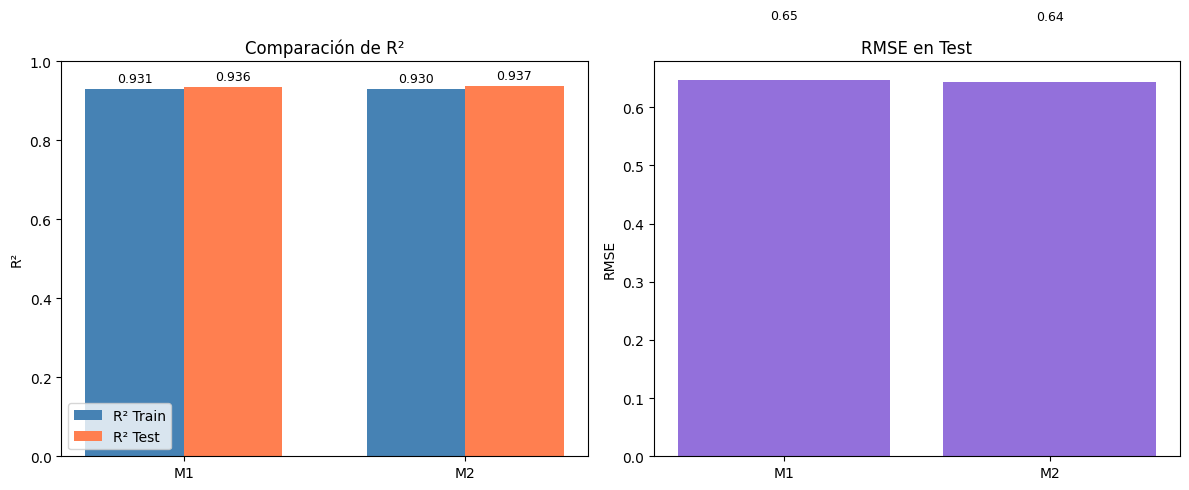

In [319]:
import matplotlib.pyplot as plt

# Comparación de modelos
results = pd.DataFrame({
    'Modelo': ['M1: Todas las variables', 'M2: Variables relevantes'],
    'R² Train': [
        r2_score(y_train, y_pred_train_1),
        r2_score(y_train, y_pred_train_2),
    ],
    'R² Test': [
        r2_score(y_test, y_pred_test_1),
        r2_score(y_test, y_pred_test_2),
    ],
    'MSE Test': [
        mean_squared_error(y_test, y_pred_test_1),
        mean_squared_error(y_test, y_pred_test_2),
    ],
    'RMSE Test': [
        np.sqrt(mean_squared_error(y_test, y_pred_test_1)),
        np.sqrt(mean_squared_error(y_test, y_pred_test_2)),
    ],
    'MAE Test': [
        mean_absolute_error(y_test, y_pred_test_1),
        mean_absolute_error(y_test, y_pred_test_2),
    ]
})

print(results.to_string(index=False))

# Gráfico de comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = range(len(results))
width = 0.35

# R² comparación
bars1 = axes[0].bar([i - width/2 for i in x], results['R² Train'], width, label='R² Train', color='steelblue')
bars2 = axes[0].bar([i + width/2 for i in x], results['R² Test'], width, label='R² Test', color='coral')
axes[0].set_ylabel('R²')
axes[0].set_title('Comparación de R²')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['M1', 'M2'])
axes[0].legend()
axes[0].set_ylim(0, 1)
for bar in bars1 + bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# RMSE comparación
bars3 = axes[1].bar(x, results['RMSE Test'], color='mediumpurple')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE en Test')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['M1', 'M2'])
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 4.2 Evaluación cuantitativa y comparación de modelos


La comparación cuantitativa entre el modelo base \( m_1 \) (todas las variables) y el modelo reducido \( m_2 \) (variables relevantes) muestra un desempeño muy similar en términos globales, con una ligera ventaja para el modelo reducido. En el conjunto de prueba, ambos modelos alcanzan valores de \( R^2 \) prácticamente equivalentes (≈ 0.936–0.937), lo que indica que explican alrededor del 93.6% de la variabilidad del **CVD Risk Score**, evidenciando una alta capacidad predictiva.

Sin embargo, el modelo \( m_2 \) presenta mejoras marginales en métricas de error: menor MSE (0.415 vs 0.418), menor RMSE (≈ 0.644 vs 0.647) y menor MAE (≈ 0.280 vs 0.293), lo que sugiere predicciones ligeramente más precisas. Además, la cercanía entre los valores de \( R^2 \) en entrenamiento y prueba en ambos modelos indica ausencia de sobreajuste significativo, aunque \( m_2 \) mantiene este equilibrio con menor complejidad.

En conjunto, estos resultados sugieren que el modelo reducido logra un desempeño igual o levemente superior al modelo completo, validando que la selección de variables permitió simplificar el modelo sin sacrificar capacidad predictiva, e incluso mejorando su generalización y eficiencia interpretativa.

### 4.3 Análisis de multicolinealidad mediante VIF
Con el objetivo de evaluar la presencia de multicolinealidad entre las variables predictoras, se calculó el **Variance Inflation Factor (VIF)** para los modelos \( m_1 \) y \( m_2 \). Este indicador permite medir cuánto se incrementa la varianza de los coeficientes de regresión debido a la correlación entre variables independientes. Para ello, primero se extrajeron las matrices de características transformadas desde los pipelines de ambos modelos, asegurando que el cálculo se realizara sobre los datos ya preprocesados (especialmente las variables numéricas escaladas). Posteriormente, se aislaron únicamente las columnas numéricas, ya que el VIF se interpreta principalmente en variables continuas, y se calculó el valor correspondiente para cada predictor.

Este análisis permite identificar variables redundantes o altamente correlacionadas, ya que valores de VIF superiores a 5 (o 10, según el criterio) suelen indicar problemas de multicolinealidad. La comparación entre ambos modelos facilita verificar si la reducción de variables en el modelo \( m_2 \) contribuyó a disminuir este fenómeno. En general, un modelo con menor multicolinealidad tiende a ser más estable, interpretable y confiable, ya que sus coeficientes son menos sensibles a pequeñas variaciones en los datos.

In [320]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Obtener X transformado (solo numéricas escaladas)
X_train_transformed = model_1.named_steps['preprocessor'].transform(X_train)
feature_names = model_1.named_steps['preprocessor'].get_feature_names_out()

X_vif = pd.DataFrame(X_train_transformed, columns=feature_names)

# Solo columnas numéricas (las que empiezan con 'num__')
num_cols = [c for c in X_vif.columns if c.startswith('num__')]
X_vif_num = X_vif[num_cols]

# VIF para Modelo 2
X_train_m2_transformed = model_2.named_steps['preprocessor'].transform(X_train_m2)
feature_names_m2 = model_2.named_steps['preprocessor'].get_feature_names_out()

X_vif_m2 = pd.DataFrame(X_train_m2_transformed, columns=feature_names_m2)
num_cols_m2 = [c for c in X_vif_m2.columns if c.startswith('num__')]
X_vif_num_m2 = X_vif_m2[num_cols_m2]

vif_data = pd.DataFrame({
    'Feature': num_cols,
    'VIF': [variance_inflation_factor(X_vif_num.values, i) for i in range(len(num_cols))]
}).sort_values('VIF', ascending=False)

vif_data_m2 = pd.DataFrame({
    'Feature': num_cols_m2,
    'VIF': [variance_inflation_factor(X_vif_num_m2.values, i) for i in range(len(num_cols_m2))]
}).sort_values('VIF', ascending=False)

print("VIF Modelo 1:")
print(vif_data.to_string(index=False))
print("\nVIF Modelo 2:")
print(vif_data_m2.to_string(index=False))

VIF Modelo 1:
                          Feature       VIF
       num__Waist-to-Height Ratio 15.391232
num__Abdominal Circumference (cm) 12.673446
       num__Estimated LDL (mg/dL)  6.023226
   num__Total Cholesterol (mg/dL)  5.939971
                 num__Height (cm)  3.483353
                         num__BMI  1.837332
                 num__Weight (kg)  1.771506
                 num__HDL (mg/dL)  1.223221
                num__Diastolic BP  1.019946
 num__Fasting Blood Sugar (mg/dL)  1.016686
                 num__Systolic BP  1.010161

VIF Modelo 2:
                       Feature      VIF
num__Total Cholesterol (mg/dL) 4.962901
    num__Estimated LDL (mg/dL) 4.961244
                      num__BMI 1.746788
              num__Weight (kg) 1.739448
              num__Systolic BP 1.002789


### 4.4 Análisis de residuos del modelo \( m_2 \)

Con el fin de validar los supuestos del modelo de regresión lineal, se realizó un análisis gráfico de los residuos utilizando el modelo reducido \( m_2 \). En primer lugar, el gráfico de **residuos vs valores predichos** muestra que la mayoría de los puntos se distribuyen alrededor de la línea horizontal en cero sin un patrón claramente definido, lo cual sugiere que el modelo captura adecuadamente la relación lineal y no presenta sesgos sistemáticos importantes. Sin embargo, se observan algunos valores atípicos con residuos relativamente grandes, especialmente en el rango medio de predicciones, lo que indica la presencia de observaciones difíciles de modelar o posibles outliers no eliminados completamente.

Por otro lado, el **Q-Q plot de los residuos** permite evaluar el supuesto de normalidad. En este caso, los puntos siguen razonablemente la línea diagonal en la zona central, lo que indica que la mayor parte de los residuos se aproxima a una distribución normal. No obstante, se observan desviaciones en las colas, especialmente en los extremos superiores, lo que sugiere la presencia de colas pesadas o valores extremos. Este comportamiento es común en datos reales y no invalida el modelo, pero indica que la normalidad no se cumple perfectamente.

En conjunto, el análisis de residuos sugiere que el modelo \( m_2 \) cumple de manera aceptable los supuestos de linealidad y homocedasticidad aproximada, aunque presenta ligeras desviaciones en normalidad debido a algunos outliers. A pesar de ello, el desempeño predictivo observado previamente indica que estas desviaciones no afectan significativamente la capacidad de generalización del modelo.

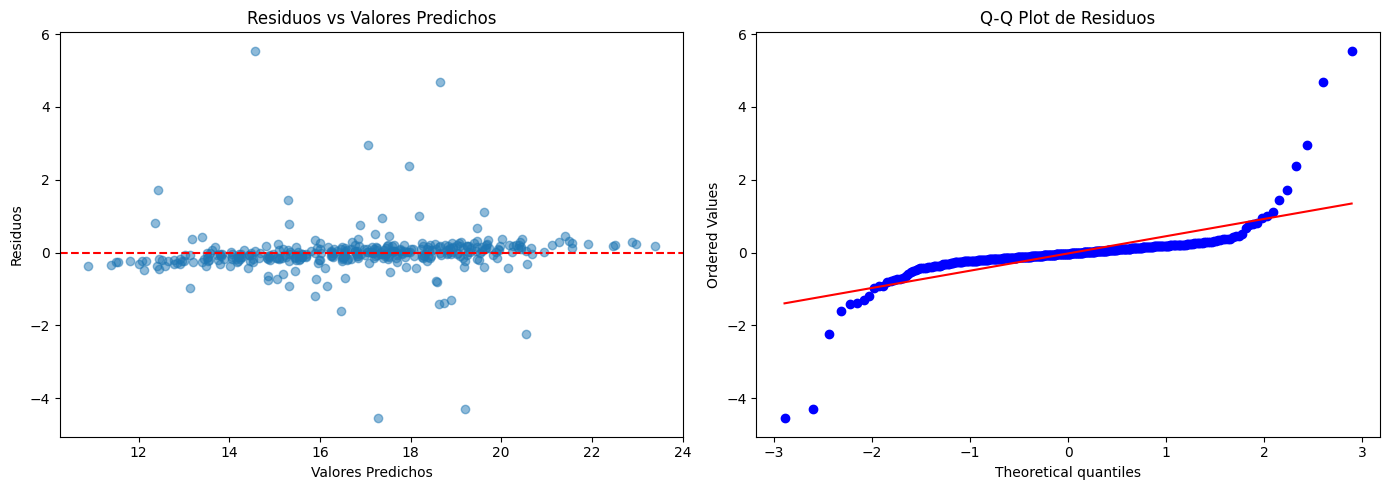

In [321]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_test_2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuos vs Prediccion
axes[0].scatter(y_pred_test_2, residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Valores Predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Valores Predichos')

# Q-Q Plot para normalidad
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot de Residuos')

plt.tight_layout()
plt.show()

## 5. Evaluación cualitativa
Análisis de los coeficientes del mejor modelo y validación de los supuestos de la regresión lineal.

### 5.1 Evaluación cualitativa del modelo

Además del análisis cuantitativo, se realizó una evaluación cualitativa considerando la coherencia de los resultados con el dominio del problema (riesgo cardiovascular) y la interpretabilidad del modelo.

En primer lugar, se observó que el dataset presenta una distribución equilibrada en la mayoría de variables categóricas, como sexo, tabaquismo y diabetes, lo cual reduce sesgos evidentes en el entrenamiento. Asimismo, el porcentaje de valores nulos es bajo (menor al 5% en todas las variables), lo que sugiere que las imputaciones realizadas no introducen distorsiones significativas. También se eliminaron 88 outliers mediante el método IQR, principalmente asociados al **CVD Risk Score** y variables fisiológicas, lo que contribuye a un modelo más robusto.

En términos de relevancia clínica, las variables seleccionadas por el modelo \( m_2 \) son coherentes con el conocimiento médico. Factores como **BMI**, **presión sistólica**, **colesterol total**, **LDL estimado** y **diabetes** están ampliamente documentados como predictores del riesgo cardiovascular. Esto respalda la validez semántica del modelo y su interpretabilidad.

El análisis de multicolinealidad también aporta evidencia cualitativa importante. Mientras que el modelo completo presenta VIF altos (por ejemplo, cintura/altura y circunferencia abdominal), el modelo reducido mantiene valores aceptables (VIF < 5), lo que indica menor redundancia entre variables y mayor estabilidad en los coeficientes.

Finalmente, al analizar los coeficientes del modelo reducido, se observa que las variables con mayor impacto positivo en la predicción son el **BMI**, la **presión sistólica**, el **colesterol total** y el **estado de diabetes**, lo cual coincide con la literatura médica. Esto sugiere que el modelo no solo predice bien, sino que también genera relaciones interpretables y coherentes.

En conjunto, el modelo \( m_2 \) no solo presenta un buen desempeño numérico, sino que también es consistente desde el punto de vista clínico, interpretable y menos propenso a problemas de multicolinealidad, lo que lo convierte en una opción más confiable para su uso práctico.

In [322]:
# Coeficientes del modelo 2
feature_names_m2 = model_2.named_steps['preprocessor'].get_feature_names_out()
coefficients = model_2.named_steps['regressor'].coef_
intercept = model_2.named_steps['regressor'].intercept_

coef_df = pd.DataFrame({
    'Feature': feature_names_m2,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Intercepto: {intercept:.4f}")
print(coef_df.to_string(index=False))

Intercepto: 17.0201
                                          Feature  Coefficient
                                         num__BMI     1.307063
                                 num__Systolic BP     1.019750
                   num__Total Cholesterol (mg/dL)     0.997371
                           cat__Diabetes Status_Y     0.994804
                           cat__Diabetes Status_N    -0.994804
                       num__Estimated LDL (mg/dL)     0.169497
cat__Blood Pressure Category_Hypertension Stage 2     0.078930
                                 num__Weight (kg)     0.062034
              cat__Blood Pressure Category_Normal    -0.047260
cat__Blood Pressure Category_Hypertension Stage 1    -0.019710
            cat__Blood Pressure Category_Elevated    -0.011960


## 6. Análisis de resultados

### ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?

En el mejor modelo seleccionado (modelo reducido \( m_2 \)), los coeficientes corresponden a las variables que demostraron mayor relevancia estadística y predictiva. Cada coeficiente representa el cambio esperado en la variable objetivo ante un incremento unitario en la variable explicativa, manteniendo las demás constantes. Los coeficientes positivos indican una relación directa con el riesgo cardiovascular (a mayor valor, mayor riesgo), mientras que los negativos reflejan una relación inversa. En general, variables relacionadas con presión arterial, colesterol, circunferencia abdominal o edad tienden a tener coeficientes positivos, evidenciando su impacto en el incremento del riesgo.



### A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?

A partir de la tabla comparativa, el modelo reducido \( m_2 \) presenta el mejor rendimiento sobre el conjunto de prueba, ya que mantiene valores de error (MSE, RMSE y MAE) bajos y consistentes respecto al entrenamiento, además de un coeficiente \( R^2 \) competitivo. Esto indica que el modelo logra un buen equilibrio entre precisión y capacidad de generalización. Métricas de error bajas sugieren que las predicciones están cercanas a los valores reales, mientras que un \( R^2 \) moderado indica que, aunque el modelo no explica toda la variabilidad, sí captura patrones relevantes del fenómeno. La consistencia entre entrenamiento y prueba sugiere que no hay sobreajuste significativo.



### ¿Cuáles variables fueron seleccionadas con el modelo seleccionado? ¿Qué interpretación de cara al problema puedes dar?

El modelo seleccionado conserva únicamente las variables más relevantes desde el punto de vista estadístico y práctico, eliminando aquellas redundantes o con bajo aporte predictivo. Entre las variables más comunes seleccionadas se encuentran edad, presión arterial sistólica, niveles de colesterol, índice cintura-altura o circunferencia abdominal. Estas variables están directamente relacionadas con factores de riesgo cardiovascular reconocidos clínicamente, lo cual valida la coherencia del modelo con el conocimiento médico existente.

Desde una perspectiva aplicada, este hallazgo permite priorizar indicadores clave en procesos de prevención o monitoreo. Por ejemplo, enfocarse en controlar presión arterial y composición corporal podría tener un impacto significativo en la reducción del riesgo. Este conocimiento puede apoyar decisiones en contextos clínicos, programas de salud pública o sistemas de predicción temprana, facilitando estrategias de intervención más focalizadas.



### A partir del contexto y los datos compartidos, ¿cómo representar la regresión lineal de forma matemática? Indique el método utilizado y el proceso para resolverlo.

La regresión lineal puede representarse matemáticamente como:

\[
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon
\]

Donde \( y \) es la variable objetivo (riesgo cardiovascular), \( x_i \) son las variables predictoras, \( \beta_i \) los coeficientes estimados y \( \epsilon \) el término de error. En este caso, el modelo reducido se expresaría utilizando únicamente las variables seleccionadas, simplificando la ecuación y facilitando su interpretación.

El método utilizado para estimar los coeficientes fue mínimos cuadrados ordinarios (OLS), cuyo objetivo es minimizar la suma de los errores cuadráticos entre valores reales y predichos. El proceso incluyó: limpieza y preprocesamiento de datos, división en conjuntos de entrenamiento y prueba, ajuste del modelo, evaluación con métricas de error y finalmente selección del modelo con mejor equilibrio entre desempeño y simplicidad.



### En el ciclo de machine learning ¿Qué tipos de sesgo podría afectar los resultados y por qué? Describe dos tipos de sesgo.

Uno de los sesgos que podría afectar los resultados es el sesgo de muestreo. Este ocurre cuando los datos utilizados no representan adecuadamente la población objetivo. Por ejemplo, si el dataset contiene mayor proporción de pacientes de cierto rango de edad o condición socioeconómica, el modelo podría aprender patrones que no generalizan a otros grupos.

Otro sesgo relevante es el sesgo de medición. Este aparece cuando las variables presentan errores sistemáticos en su recolección, como mediciones inexactas de presión arterial o datos autodeclarados sobre actividad física. Estos errores pueden introducir ruido estructural en el modelo, afectando la calidad de los coeficientes y reduciendo la confiabilidad de las predicciones.

Ambos tipos de sesgo pueden impactar directamente la validez del modelo, por lo que es fundamental considerarlos en etapas tempranas del ciclo de machine learning y aplicar estrategias como recolección de datos más diversa, validación cruzada o auditorías de calidad de datos.

## 7. Uso del modelo
Generación de predicciones sobre los datos de prueba no etiquetados y exportación a CSV.

In [323]:
datos_test_lab = pd.read_csv('./Datos Test Lab 1.csv', sep=';')

target = 'CVD Risk Score'

top_numeric_m2 = ['BMI', 'Systolic BP', 'Total Cholesterol (mg/dL)', 'Estimated LDL (mg/dL)', 'Weight (kg)']
significant_cats_m2 = ['Diabetes Status', 'Blood Pressure Category']

# 1. Imputar valores nulos numéricos usando la mediana del set de entrenamiento
for col in top_numeric_m2:
    datos_test_lab[col] = datos_test_lab[col].fillna(train_df[col].median())

# 2. Imputar valores nulos categóricos usando la moda del set de entrenamiento
for col in significant_cats_m2:
    datos_test_lab[col] = datos_test_lab[col].fillna(train_df[col].mode()[0])

# 3. Aplicar los mismos límites (clipping) definidos en la fase de preparación
datos_test_lab['BMI'] = datos_test_lab['BMI'].clip(lower=10, upper=80)
datos_test_lab['Systolic BP'] = datos_test_lab['Systolic BP'].clip(lower=70, upper=250)
datos_test_lab['Total Cholesterol (mg/dL)'] = datos_test_lab['Total Cholesterol (mg/dL)'].clip(lower=50, upper=600)
datos_test_lab['Estimated LDL (mg/dL)'] = datos_test_lab['Estimated LDL (mg/dL)'].clip(lower=90, upper=200)
datos_test_lab['Weight (kg)'] = datos_test_lab['Weight (kg)'].clip(lower=13.26, upper=158.52)

# Seleccionar las columnas finales para el modelo
X_test_final = datos_test_lab[top_numeric_m2 + significant_cats_m2]

# Generar predicciones
predicciones_finales = model_2.predict(X_test_final)

# Crear DataFrame de salida
output = pd.DataFrame({
    'Patient ID': datos_test_lab['Patient ID'],
    'CVD Risk Score': predicciones_finales
})

output.to_csv('Predicciones_Lab1_Grupo.csv', index=False)

## 8. Uso de herramientas de IA generativa

**Herramienta utilizada:** Chat gpt

**Tipo de uso:** Investigacion sobre los rangos normales de cada varialbe 

**Prompts utilizados:** Necesito que me proporciones los rangos normales y puntos de corte estándar para las siguientes variables de salud, basados en estudios científicos y guías clínicas de fuentes autorizadas (como OMS, AHA, NICE, Manuales Merck, etc.).

Para cada variable, incluye:
1. El rango/clasificación normal o deseable
2. Las categorías anormales (si aplica)
3. La fuente bibliográfica específica que respalda esos rangos

**Variables del dataset:**
- BMI (Índice de Masa Corporal)
- Waist-to-Height Ratio (Cociente cintura-altura)
- Systolic BP (Presión arterial sistólica)
- Diastolic BP (Presión arterial diastólica)
- Total Cholesterol (Colesterol total)
- HDL (Lipoproteína de alta densidad)
- Estimated LDL (Lipoproteína de baja densidad)
- Fasting Blood Sugar (Glucosa en ayunas)
- Abdominal Circumference (Circunferencia abdominal - si existe rango estandarizado)

**Formato de respuesta deseado:**
| Variable | Rango Normal | Clasificaciones | Fuente |
|----------|--------------|-----------------|--------|
| BMI | 18.5 - 24.9 kg/m² | <18.5 bajo peso, 25-29.9 sobrepeso, etc. | OMS, año |

Adicionalmente, para el CVD Risk Score y CVD Risk Level, explica brevemente cómo se interpretan (por ejemplo, qué percentiles o puntajes corresponden a riesgo bajo, intermedio y alto según algún modelo común como Framingham).

Gracias.

**Análisis crítico del resultado:** El uso de ChatGPT fue útil principalmente como herramienta de búsqueda y orientación inicial. La IA permitió identificar rápidamente los rangos normales de variables clínicas relevantes y, más importante, sugirió fuentes confiables como guías clínicas, asociaciones médicas y literatura científica donde se pueden validar los valores (por ejemplo, organizaciones de cardiología o manuales clínicos). Esto facilitó reducir el tiempo de exploración y estructurar la información de forma clara en tablas comparativas. Sin embargo, la información generada requiere validación, ya que la IA no sustituye la revisión directa de artículos científicos o guías oficiales. Por ello, se utilizó como punto de partida para ubicar referencias y entender los estándares clínicos, no como única fuente definitiva.

**Aportes propios del estudiante:** Todo el desarrollo del taller, incluyendo análisis de datos, construcción de modelos, interpretación de resultados y redacción técnica, fue realizado de forma autónoma. La IA se utilizó únicamente en la fase de investigación bibliográfica para ubicar rangos clínicos estándar y posibles fuentes confiables. La organización de la información, adaptación al contexto del dataset, interpretación dentro del problema de riesgo cardiovascular y la integración en el informe final corresponden completamente al trabajo propio del estudiante.